In [21]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


#### Set up [ts-mule](https://github.com/dbvis-ukon/ts-mule)

In [22]:
import sys

try:
    from tsmule.xai.lime import LimeTS # noqa: F401 # type: ignore[reportMissingImports]
except ModuleNotFoundError:
    !mkdir dependencies
    !cd dependencies && git clone https://github.com/dbvis-ukon/ts-mule.git

    sys.path.append("./dependencies/ts-mule")

    # Install dependencies
    %pip install -q dill stumpy pyts matplotlib numpy

# Test installation
from tsmule.xai.lime import LimeTS # type: ignore[reportMissingImports]
print("tsmule package successfully installed")

tsmule package successfully installed


In [23]:
from utils.datasets import load_dataset

# See `utils/datasets.py` for the exact type of `data`
data = load_dataset("finance")

✅ Loaded finance

Summary:

FINANCE
Train shape: (1200, 3)
Test shape: (300, 3)
Train columns: ['series_id', 'timestamp', 'value']
Unique train series: 6
Unique test series: 6


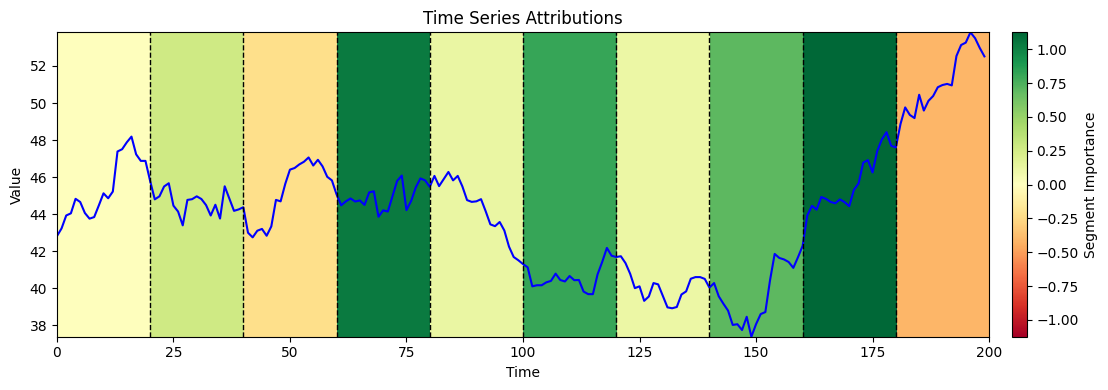

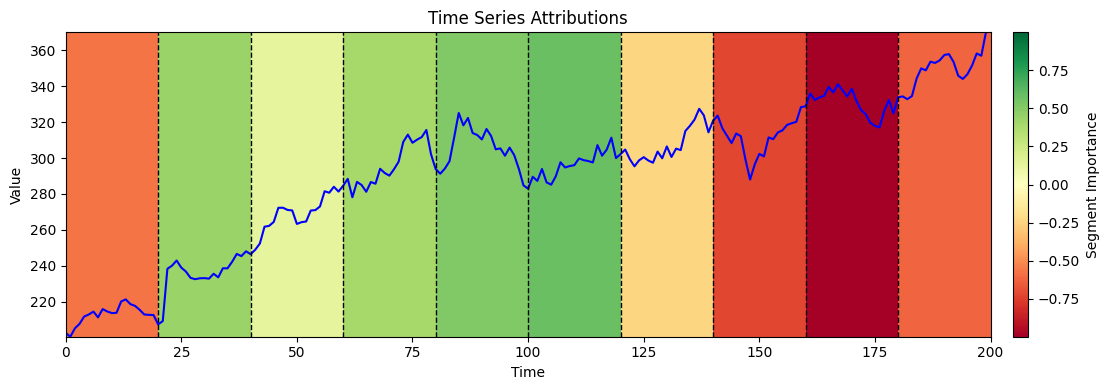

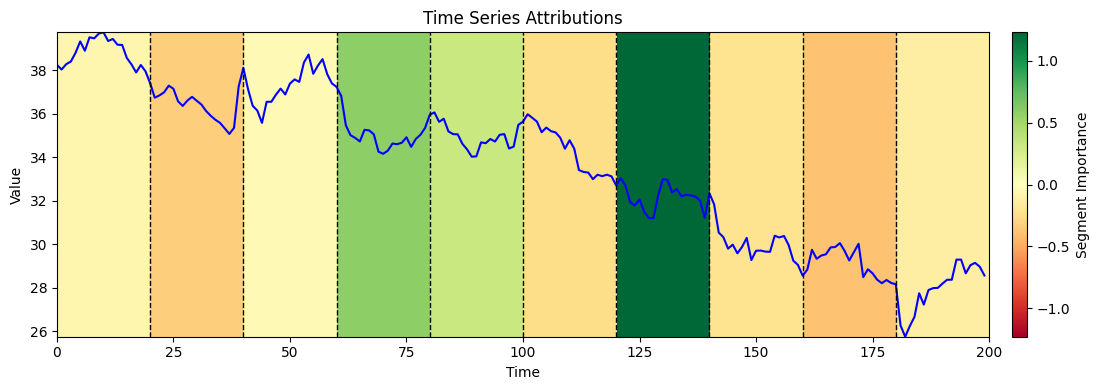

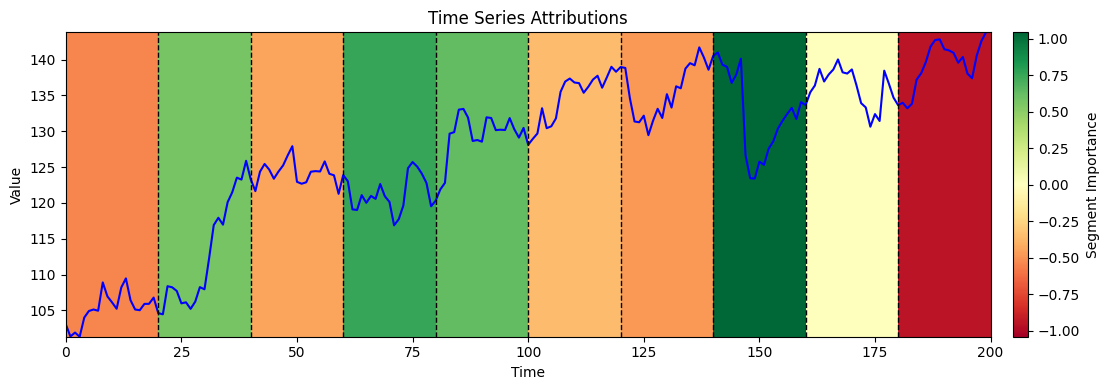

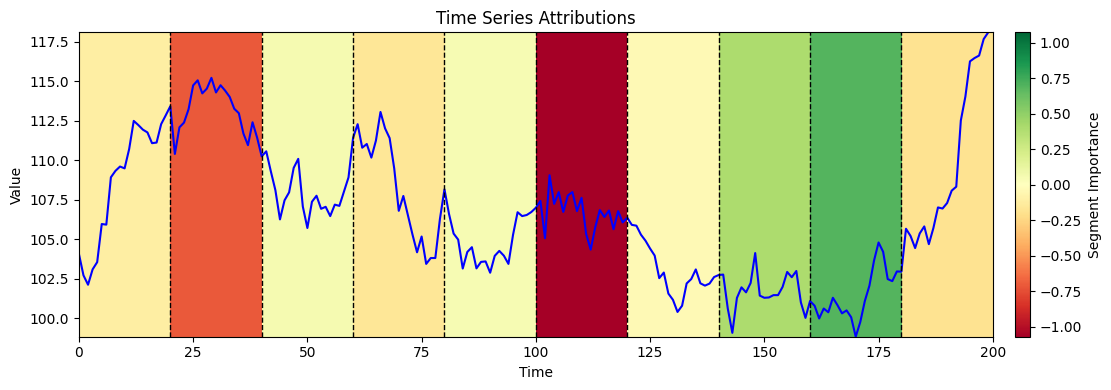

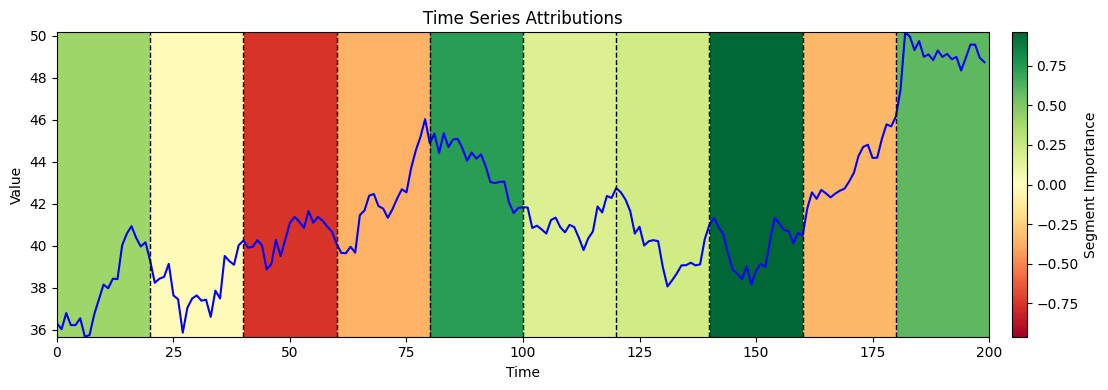

In [24]:
import numpy as np

from tsmule.sampling.perturb import Perturbation
from tsmule.xai.lime import LimeTS, Kernels

from utils.segmentation import UniformSegmentation
from utils.random_walk import generate_random_walk
from utils.visualization import visualize_segmentation_heatmap

# Index in the forecast to explain.
# This corresponds to the last point in the forecast (len(test) - 1)
index_to_explain = -1

cfg = {
    'lime_cfg': {
        'partitions': 10,
        # Since this is a random walk so increasing n_samples makes the importances converge to 0
        # 'n_samples': 10_000,
        'n_samples': 1_000,
        'perturbation_method': 'zeros',
    },
    # This is for zooming in on the end of the input time series
    'suffix_len': None, 
}

# Factory function
def create_predict_fn(index_to_explain, model_cfg, prefix):
    def predict_fn(X):
        X_full = np.vstack((prefix, X)) # Not actually needed

        pred = generate_random_walk(n_steps=index_to_explain + 1)

        return np.array(pred[index_to_explain])
    return predict_fn


for series in data:
    train = np.array(series['train'])
    test = np.array(series['test'])

    # Suffix logic (zooming in on the end of a time-series)
    X_full = train
    X = X_full.copy()
    prefix = np.empty((0, 1))
    if cfg['suffix_len']:
        X = X_full[:-cfg['suffix_len']]
        prefix = X_full[-cfg['suffix_len']:]

    # Convert relative index to absolute
    abs_index = index_to_explain
    if index_to_explain < 0:
        abs_index = len(test) + index_to_explain

    segmenter = UniformSegmentation(cfg['lime_cfg']['partitions'])

    explainer = LimeTS(
        kernel = Kernels.Lasso,
        sampler = Perturbation(p_off = 0.5, method = cfg['lime_cfg']['perturbation_method'], n_samples=cfg['lime_cfg']['n_samples']),
        segmenter = segmenter,
    )

    explanation = explainer.explain(
        x = X,
        predict_fn = create_predict_fn(abs_index, {}, prefix),
        # Other options available for other segmentation methods. Ex. For MatrixProfile add `segmentation_method = '...'`
    )

    plt = visualize_segmentation_heatmap(
        time_series_sample = X,
        importance_mask = explanation,
        segmentation_mask = segmenter.segment(X),
        title="Time Series Attributions",
    )

    plt.show()
    
